# **Main Imports**

In [174]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

## *global file config*

In [175]:
BASE = os.getcwd()

DATASETS_DIR = "datasets"
DATASETS_PATH = os.path.join(BASE, DATASETS_DIR)

FILE_NAME = "Credit Card Defaulter Prediction.csv"
FILE_PATH = os.path.join(DATASETS_PATH, FILE_NAME)

## **Part A**

In [176]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

In [177]:
df_a = pd.read_csv(FILE_PATH)

In [178]:
df_a.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,F,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,Y
1,2,120000,F,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,Y
2,3,90000,F,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,N
3,4,50000,F,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,N
4,5,50000,M,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,N


In [179]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         30000 non-null  int64 
 1   LIMIT_BAL  30000 non-null  int64 
 2   SEX        30000 non-null  object
 3   EDUCATION  30000 non-null  object
 4   MARRIAGE   30000 non-null  object
 5   AGE        30000 non-null  int64 
 6   PAY_0      30000 non-null  int64 
 7   PAY_2      30000 non-null  int64 
 8   PAY_3      30000 non-null  int64 
 9   PAY_4      30000 non-null  int64 
 10  PAY_5      30000 non-null  int64 
 11  PAY_6      30000 non-null  int64 
 12  BILL_AMT1  30000 non-null  int64 
 13  BILL_AMT2  30000 non-null  int64 
 14  BILL_AMT3  30000 non-null  int64 
 15  BILL_AMT4  30000 non-null  int64 
 16  BILL_AMT5  30000 non-null  int64 
 17  BILL_AMT6  30000 non-null  int64 
 18  PAY_AMT1   30000 non-null  int64 
 19  PAY_AMT2   30000 non-null  int64 
 20  PAY_AMT3   30000 non-null  i

In [180]:
df_a.columns = df_a.columns.str.strip()

In [181]:
df_a['default'].value_counts()

default
N    23364
Y     6636
Name: count, dtype: int64

In [182]:
df_a.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [183]:
df_a.drop(['ID'], axis=1, inplace=True)

In [184]:
cat_data = df_a.select_dtypes(include=['object']).columns.to_list()

In [185]:
cat_data

['SEX', 'EDUCATION', 'MARRIAGE', 'default']

In [186]:
encoder = LabelEncoder()
for col in cat_data:
    df_a[col] = encoder.fit_transform(df_a[col].astype(str))

In [187]:
df_a.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,0,4,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,0,4,3,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,0,4,3,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,0,4,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,4,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [188]:
X = df_a.drop(['default'], axis=1)
y = df_a['default']

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [190]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [191]:
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=scaler.get_feature_names_out(X_train.columns))
X_test = pd.DataFrame(scaler.transform(X_test), columns=scaler.get_feature_names_out(X_test.columns))

In [192]:
feature_scorer = mutual_info_classif(X_train, y_train)
feature_scores = pd.DataFrame({'feature': X_train.columns, 'feature_score': feature_scorer.tolist()}).sort_values(by='feature_score', ascending=False)

In [193]:
selected = feature_scores[feature_scores['feature_score'] > 0.01]['feature'].tolist()

In [194]:
X_train = X_train[selected]
X_test = X_test[selected]

In [195]:
def plot_probabilities(X_test, y_test, classifier):
    try:
        pred_probs = classifier.predict_proba(X_test)[:, 1]
        title = 'Receiver Operating Characteristic (ROC) Curve | {}'.format(classifier.__class__.__name__)
    except AttributeError:
        pred_probs = classifier.predict(X_test)
        title = 'Receiver Operating Characteristic (ROC) Curve | Probit Model'
    fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

### **LogisticRegression**

In [196]:
from sklearn.linear_model import LogisticRegression

In [197]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_preds_lr = lr.predict(X_test)

In [198]:
clf_report_lr = classification_report(y_test, y_preds_lr, output_dict=True)
clf_report_lr

{'0': {'precision': 0.8157660067772428,
  'recall': 0.975890761681246,
  'f1-score': 0.8886730134058675,
  'support': 4687.0},
 '1': {'precision': 0.712468193384224,
  'recall': 0.21325209444021326,
  'f1-score': 0.32825322391559203,
  'support': 1313.0},
 'accuracy': 0.809,
 'macro avg': {'precision': 0.7641171000807334,
  'recall': 0.5945714280607296,
  'f1-score': 0.6084631186607298,
  'support': 6000.0},
 'weighted avg': {'precision': 0.7931610019464037,
  'recall': 0.809,
  'f1-score': 0.7660344828057455,
  'support': 6000.0}}

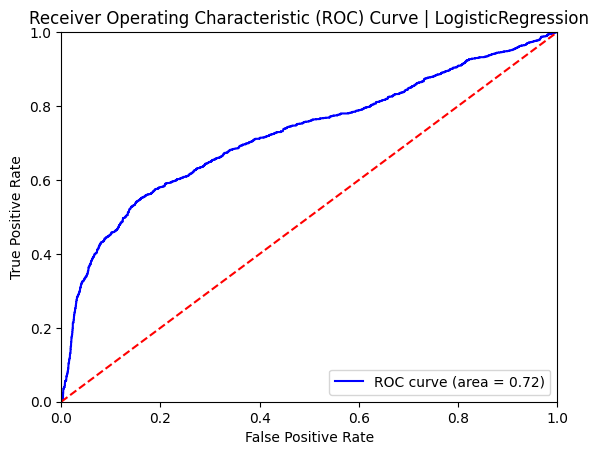

In [199]:
plot_probabilities(X_test, y_test, lr)

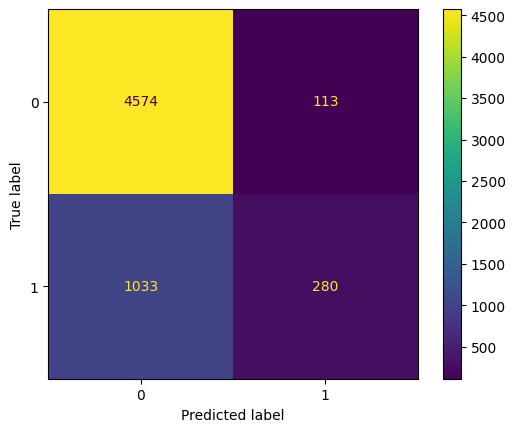

In [200]:
# Compute the confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_preds_lr)

# Display the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr).plot()
plt.show()

### **DecisionTree**

In [201]:
from sklearn.tree import DecisionTreeClassifier

In [202]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_preds_dt = dt.predict(X_test)

In [203]:
clf_report_dt = classification_report(y_test, y_preds_dt, output_dict=True)
clf_report_dt

{'0': {'precision': 0.8229342327150084,
  'recall': 0.8329421804992533,
  'f1-score': 0.8279079631004135,
  'support': 4687.0},
 '1': {'precision': 0.3765923566878981,
  'recall': 0.3602437166793602,
  'f1-score': 0.3682366679641884,
  'support': 1313.0},
 'accuracy': 0.7295,
 'macro avg': {'precision': 0.5997632947014533,
  'recall': 0.5965929485893068,
  'f1-score': 0.5980723155323009,
  'support': 6000.0},
 'weighted avg': {'precision': 0.7252597521777425,
  'recall': 0.7295,
  'f1-score': 0.7273165613481029,
  'support': 6000.0}}

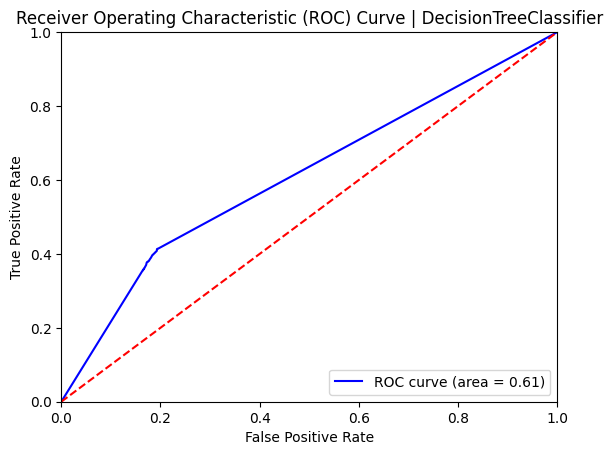

In [204]:
plot_probabilities(X_test, y_test, dt)

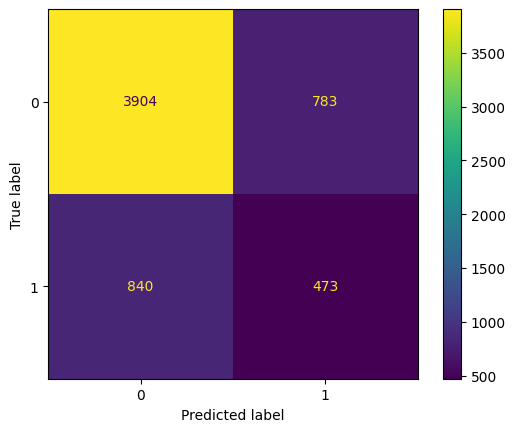

In [205]:
# Compute the confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_preds_dt)

# Display the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_dt).plot()
plt.show()

In [206]:
clf_report_dt

{'0': {'precision': 0.8229342327150084,
  'recall': 0.8329421804992533,
  'f1-score': 0.8279079631004135,
  'support': 4687.0},
 '1': {'precision': 0.3765923566878981,
  'recall': 0.3602437166793602,
  'f1-score': 0.3682366679641884,
  'support': 1313.0},
 'accuracy': 0.7295,
 'macro avg': {'precision': 0.5997632947014533,
  'recall': 0.5965929485893068,
  'f1-score': 0.5980723155323009,
  'support': 6000.0},
 'weighted avg': {'precision': 0.7252597521777425,
  'recall': 0.7295,
  'f1-score': 0.7273165613481029,
  'support': 6000.0}}

In [207]:
def parse_clf_report(clf_report):
    report = {}
    for key, value in clf_report.items():
        if key in y_test.unique().astype(str).tolist():
            report[key] = {k: v for k, v in value.items()}
    return report

In [208]:
lr_clf_df = pd.DataFrame(parse_clf_report(clf_report_lr)).T
lr_clf_df['model'] = 'Logistic Regression'
dt_clf_df = pd.DataFrame(parse_clf_report(clf_report_dt)).T
dt_clf_df['model'] = 'Decision Tree Classifier'

In [209]:
comparison_df = pd.concat([lr_clf_df, dt_clf_df], axis=0).reset_index()
comparison_df = comparison_df[['model', 'precision', 'recall', 'f1-score', 'support']]

In [210]:
comparison_df

,model,precision,recall,f1-score,support
0,Logistic Regression,0.815766,0.975891,0.888673,4687.0
1,Logistic Regression,0.712468,0.213252,0.328253,1313.0
2,Decision Tree Classifier,0.822934,0.832942,0.827908,4687.0
3,Decision Tree Classifier,0.376592,0.360244,0.368237,1313.0


## **Part B**

In [211]:
from statsmodels.discrete.discrete_model import Probit

In [212]:
pt = Probit(y_train, X_train)
pt_res = pt.fit()
print(pt_res.summary())

Optimization terminated successfully.
         Current function value: 0.532521
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                default   No. Observations:                24000
Model:                         Probit   Df Residuals:                    23987
Method:                           MLE   Df Model:                           12
Date:                Mon, 30 Jun 2025   Pseudo R-squ.:               -0.006340
Time:                        18:31:54   Log-Likelihood:                -12781.
converged:                       True   LL-Null:                       -12700.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PAY_0          0.9432      0.099      9.492      0.000       0.748       1.138
PAY_2         -0.1126      0.

In [213]:
y_preds_probs_pt = pt_res.predict(X_test)
y_preds_pt = (y_preds_probs_pt > 0.5).astype(int)

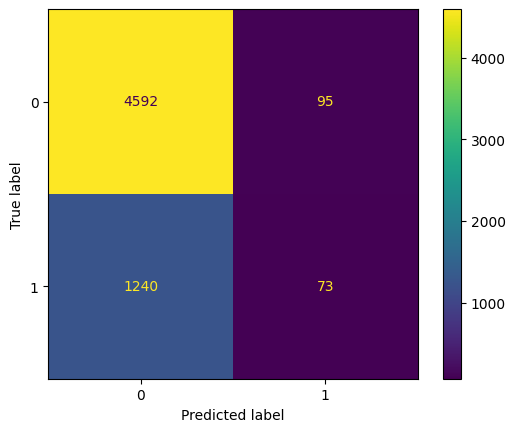

In [214]:
# Compute the confusion matrix
conf_matrix_pt = confusion_matrix(y_test, y_preds_pt)

# Display the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix_pt).plot()
plt.show()

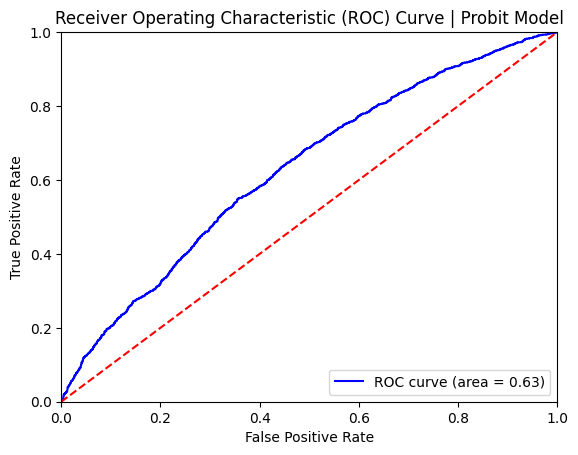

In [215]:
plot_probabilities(X_test, y_test, pt_res)